# 05.03 · k vecinos más cercanos (k-NN)

**Objetivo:** entender el único modelo de este bloque que **no entrena nada**. No hay
pesos, no hay ecuación, no hay optimización: solo memoria y distancia. Y precisamente
por eso deja al descubierto dos cosas que en otros modelos quedan escondidas — la
importancia de **la escala de las variables** y el compromiso entre **memorizar y
generalizar**.

📖 Teoría: [5.1 Modelos clásicos](../../../../../docs/02-deep-learning/05-tipos-de-modelo/5.1-modelos-clasicos.md)

In [1]:
# --- Bootstrap: local o Colab ---------------------------------------------
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/TU_USUARIO/dl-lab.git"

if IN_COLAB:
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/dl-lab"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "/content/dl-lab"], check=True)
    sys.path.insert(0, "/content/dl-lab/src")

print("Ejecutando en:", "Google Colab" if IN_COLAB else "Local (Docker)")

Ejecutando en: Local (Docker)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from dllab import set_seed

set_seed(42)

42

## 1. El caso de uso

Trabajas en un jardín botánico. Llega un lirio sin etiquetar y hay que decir a qué
especie pertenece. Tienes una regla y una libreta con **150 lirios ya identificados**,
cada uno con cuatro medidas: largo y ancho del sépalo, largo y ancho del pétalo.

El enfoque más humano posible: **busca en la libreta los lirios que más se parecen a
este y mira qué eran**. Eso es k-NN, literalmente.

(El conjunto *Iris* lo recopiló el botánico Edgar Anderson en 1935 y lo hizo famoso el
estadístico Ronald Fisher; es probablemente el dataset más usado de la historia.)

In [3]:
iris = load_iris()
X, y = iris.data, iris.target

print(f"{X.shape[0]} lirios, {X.shape[1]} medidas cada uno")
print(f"Especies: {', '.join(iris.target_names)}")
print(f"Medidas: {', '.join(iris.feature_names)}")
print(f"Reparto: {np.bincount(y)} — perfectamente equilibrado")

150 lirios, 4 medidas cada uno
Especies: setosa, versicolor, virginica
Medidas: sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)
Reparto: [50 50 50] — perfectamente equilibrado


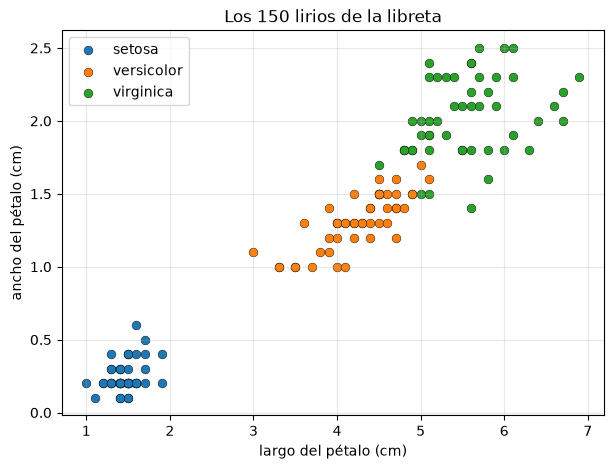

In [4]:
# Nos quedamos con las dos medidas del pétalo para poder dibujarlo en un plano
X2 = X[:, 2:4]

plt.figure(figsize=(7, 5))
for clase, nombre in enumerate(iris.target_names):
    plt.scatter(X2[y == clase, 0], X2[y == clase, 1], s=40, label=nombre,
                edgecolor="k", linewidth=0.3)
plt.xlabel("largo del pétalo (cm)")
plt.ylabel("ancho del pétalo (cm)")
plt.title("Los 150 lirios de la libreta")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

*Setosa* se separa sola; *versicolor* y *virginica* se solapan en la zona central. Ahí
es donde el modelo se va a jugar los aciertos.

## 2. La idea en una frase

**Para clasificar algo nuevo, mira sus `k` ejemplos más parecidos y quédate con la
clase que más se repita entre ellos.**

"Parecido" es distancia euclídea: la de toda la vida, la del teorema de Pitágoras
extendido a más dimensiones.

Lo que hace a k-NN raro entre todos los modelos: **`fit()` no calcula nada**. Solo
guarda los datos. Todo el trabajo ocurre en `predict()`, cuando toca medir distancias.
Por eso se le llama un modelo *perezoso* (*lazy learner*).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.3, random_state=42, stratify=y
)

modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_train, y_train)   # esto es instantáneo: solo memoriza

print(f"Acierto en test: {modelo.score(X_test, y_test):.1%}")

Acierto en test: 93.3%


## 3. Verlo de verdad: ¿quiénes son los vecinos?

Cojamos un lirio concreto del conjunto de test y veamos qué mira el modelo para decidir.

In [6]:
lirio_nuevo = X_test[0].reshape(1, -1)
distancias, indices = modelo.kneighbors(lirio_nuevo)

print(f"Lirio a clasificar: pétalo de {lirio_nuevo[0, 0]} × {lirio_nuevo[0, 1]} cm")
print(f"Su especie real es: {iris.target_names[y_test[0]]}\n")
print("Sus 5 vecinos más cercanos en la libreta:")
for dist, idx in zip(distancias[0], indices[0]):
    print(f"  distancia {dist:.2f} cm → {iris.target_names[y_train[idx]]}")

votos = np.bincount(y_train[indices[0]], minlength=3)
print("\nVotación:")
for nombre, n in zip(iris.target_names, votos):
    print(f"  {nombre:12} {n} voto(s)")
print(f"\nDecisión: {iris.target_names[votos.argmax()]}")

Lirio a clasificar: pétalo de 6.3 × 1.8 cm
Su especie real es: virginica

Sus 5 vecinos más cercanos en la libreta:
  distancia 0.22 cm → virginica
  distancia 0.22 cm → virginica
  distancia 0.30 cm → virginica
  distancia 0.42 cm → virginica
  distancia 0.45 cm → virginica

Votación:
  setosa       0 voto(s)
  versicolor   0 voto(s)
  virginica    5 voto(s)

Decisión: virginica


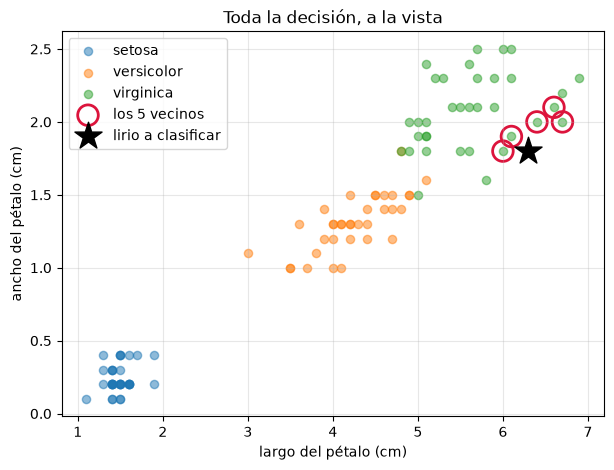

In [7]:
plt.figure(figsize=(7, 5))
for clase, nombre in enumerate(iris.target_names):
    plt.scatter(X_train[y_train == clase, 0], X_train[y_train == clase, 1],
                s=35, alpha=0.5, label=nombre)
plt.scatter(X_train[indices[0], 0], X_train[indices[0], 1], s=220,
            facecolors="none", edgecolors="crimson", linewidths=2, label="los 5 vecinos")
plt.scatter(lirio_nuevo[0, 0], lirio_nuevo[0, 1], marker="*", s=420,
            c="black", label="lirio a clasificar", zorder=5)
plt.xlabel("largo del pétalo (cm)")
plt.ylabel("ancho del pétalo (cm)")
plt.title("Toda la decisión, a la vista")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

No hay nada más. Ni pesos, ni fórmula, ni caja negra: la explicación de la predicción
**son los cinco lirios señalados**. Como transparencia, es difícil de superar.

## 4. El único mando: `k`

`k = 1` significa copiar la etiqueta del vecino más próximo, sin más. La frontera sale
retorcida y cada punto ruidoso se lleva su propia islita: eso es **memorizar**.

Subir `k` obliga a votar a más vecinos, así que un ejemplo raro queda en minoría y la
frontera se suaviza: eso es **generalizar**.

Pasarse también se paga: con `k` demasiado grande votan lirios que ya no se parecen en
nada, y las clases minoritarias quedan aplastadas.

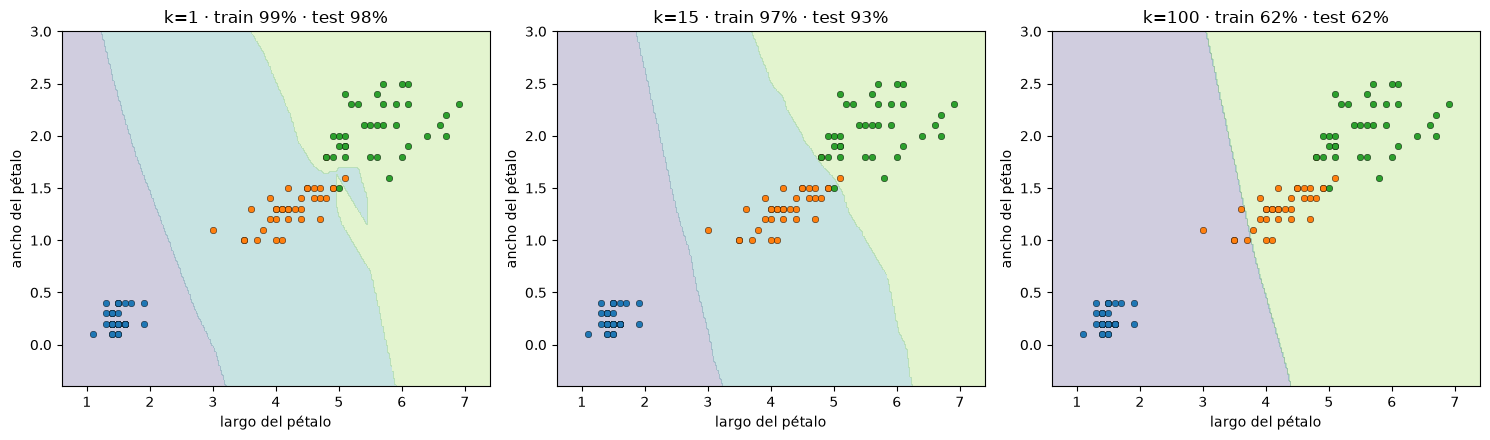

In [8]:
def dibujar_frontera(modelo, X, y, ax, titulo):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, levels=2)
    for clase in range(3):
        ax.scatter(X[y == clase, 0], X[y == clase, 1], s=22, edgecolor="k", linewidth=0.3)
    ax.set_title(titulo)
    ax.set_xlabel("largo del pétalo")
    ax.set_ylabel("ancho del pétalo")


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, k in zip(axes, [1, 15, 100]):
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    dibujar_frontera(m, X_train, y_train, ax,
                     f"k={k} · train {m.score(X_train, y_train):.0%} · test {m.score(X_test, y_test):.0%}")
plt.tight_layout()
plt.show()

`k=1` acierta el **100 % en entrenamiento** — evidentemente: el vecino más cercano de
un punto que está en la libreta es él mismo. Ese 100 % no significa nada. Es el
ejemplo más limpio que existe de por qué **nunca se evalúa sobre los datos de
entrenamiento**.

`k=100`, en el otro extremo, borra la frontera entre *versicolor* y *virginica*.

## 5. Elegir `k` con criterio

En vez de mirar las tres imágenes y decidir a ojo, probamos todos los valores con
**validación cruzada**: partir el entrenamiento en 5 trozos, entrenar con 4 y evaluar
con el que queda, cinco veces, y promediar.

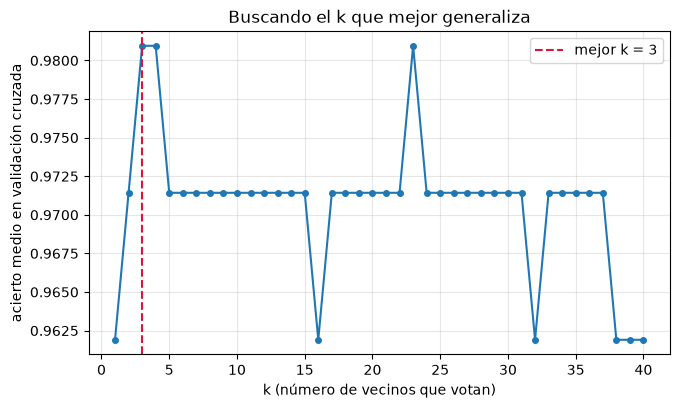

Con k=3, acierto en test: 93.3%


In [9]:
ks = range(1, 41)
medias = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=5).mean()
          for k in ks]

mejor_k = ks[int(np.argmax(medias))]

plt.figure(figsize=(7.5, 4.2))
plt.plot(ks, medias, marker="o", ms=4)
plt.axvline(mejor_k, ls="--", c="crimson", label=f"mejor k = {mejor_k}")
plt.xlabel("k (número de vecinos que votan)")
plt.ylabel("acierto medio en validación cruzada")
plt.title("Buscando el k que mejor generaliza")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

modelo_final = KNeighborsClassifier(n_neighbors=mejor_k).fit(X_train, y_train)
print(f"Con k={mejor_k}, acierto en test: {modelo_final.score(X_test, y_test):.1%}")

## 6. La trampa que hunde a k-NN: la escala

Esto es lo más importante del cuaderno. k-NN decide por **distancia**, así que la
variable medida en números más grandes domina el cálculo, aunque sea la menos
informativa.

Simulémoslo: alguien anota el largo del sépalo en **milímetros** en vez de en
centímetros. El dato es el mismo, solo cambia la unidad.

In [10]:
X4 = X.copy()
X4_mm = X.copy()
X4_mm[:, 0] *= 10  # el largo del sépalo pasa a milímetros

Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X4, y, test_size=0.3, random_state=42, stratify=y)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X4_mm, y, test_size=0.3, random_state=42, stratify=y)

sin_escalar_cm = KNeighborsClassifier(n_neighbors=5).fit(Xa_tr, ya_tr).score(Xa_te, ya_te)
sin_escalar_mm = KNeighborsClassifier(n_neighbors=5).fit(Xb_tr, yb_tr).score(Xb_te, yb_te)

# El mismo modelo, pero normalizando cada variable antes de medir distancias
con_escalado = make_pipeline(
    StandardScaler(), KNeighborsClassifier(n_neighbors=5)
).fit(Xb_tr, yb_tr).score(Xb_te, yb_te)

print(f"Todo en cm, sin escalar         : {sin_escalar_cm:.1%}")
print(f"Sépalo en mm, sin escalar       : {sin_escalar_mm:.1%}   ← misma información, peor resultado")
print(f"Sépalo en mm, con StandardScaler: {con_escalado:.1%}   ← recupera buena parte")

Todo en cm, sin escalar         : 97.8%
Sépalo en mm, sin escalar       : 84.4%   ← misma información, peor resultado
Sépalo en mm, con StandardScaler: 91.1%   ← recupera buena parte


Cambiar una unidad de medida —sin añadir ni quitar un solo dato— **le cuesta al modelo
más de trece puntos de acierto**. Eso no debería poder pasar, y pasa porque el largo
del sépalo, ahora medido en números diez veces mayores, se come el cálculo de la
distancia: los pétalos, que son las medidas que de verdad distinguen las especies,
dejan de contar.

`StandardScaler` pone cada variable en media 0 y desviación 1, y recupera buena parte
de lo perdido. Fíjate en que **no llega al 97,8 % original**: en este dataset los
centímetros ya repartían los pesos de forma casualmente favorable a los pétalos, y
normalizar iguala todas las medidas, incluidas las poco informativas. Escalar no es
magia, es quitar de en medio un artefacto de las unidades.

**Regla práctica: con k-NN, escala siempre.** Y hazlo dentro de un `Pipeline`, para que
el escalador se ajuste solo con los datos de entrenamiento y no se cuele información
del test.

## 7. Cuándo usarlo y cuándo no

**Úsalo cuando:**

- Quieres una **línea base en cinco minutos**. No hay nada que configurar salvo `k`.
- Necesitas explicar cada predicción señalando casos concretos ("este cliente se parece
  a estos cinco"). Es el modelo más auditable que hay.
- Las clases tienen formas raras: k-NN no asume ninguna forma de frontera.

**No lo uses cuando:**

- Tienes muchos datos: cada predicción compara con **todo** el conjunto guardado. Es
  barato de entrenar y caro de usar, justo al revés que los demás.
- Tienes muchas variables. Con decenas de dimensiones, las distancias entre todos los
  puntos se vuelven casi iguales y "el más cercano" deja de significar nada — es la
  **maldición de la dimensionalidad**.
- Hay variables en escalas distintas y no puedes escalar.

## 8. Prueba tú

1. Usa las 4 medidas en vez de 2 (`X` en lugar de `X2`). ¿Sube el acierto?
2. Prueba `weights="distance"`: los vecinos más próximos pesan más en la votación.
   ¿Cambia algo con `k` grande?
3. Añade 20 columnas de ruido puro (`np.hstack([X, rng.normal(size=(150, 20))])`) y
   mira cómo cae el acierto. Acabas de tocar la maldición de la dimensionalidad.
4. Con `k=2` (par) puede haber empates. ¿Cómo los resuelve scikit-learn? Compruébalo.